# POACH — Second Zone Validation: Black and White Glades

This notebook applies the POACH model — developed and tuned on the Maple Villa
zone — to a **second, independent zone**: the Black and White Glades near
Rumford, ME. The purpose is an out-of-sample test: does a model that showed a
weak positive signal at Maple Villa *generalize* to a zone it was never tuned
on?

Because Black and White is a large zone, the analysis is run on a ~2.2 km
sub-area (clipped to fit the Earth Engine export size limit) at the same 1 m
canopy resolution used for Maple Villa, so the two zones are directly comparable.
The full pipeline is unchanged — the same `src/` modules and scoring functions
are applied via a new zone configuration.

In [1]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
import ee

from src.zones import ZONES
from src.run import run_zone
from src.validation import plot_overlay

ee.Initialize(project="poach-501022")

## Running the model on a new zone

Thanks to the refactored, config-driven pipeline, running an entirely new zone
requires only a zone definition and a single call to `run_zone`. The same
canopy gap-structure, terrain scoring, and combination logic used for Maple
Villa are applied here without modification — the point of an honest
generalization test is to change nothing but the location.

Canopy already on disk: ../data/raw/black_and_white_sub_canopy_1m.tif


/opt/homebrew/Caskroom/miniforge/base/envs/geo/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  ds = xr.merge(
/opt/homebrew/Caskroom/miniforge/base/envs/geo/lib/python3.11/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  ds = xr.merge(
/opt/homebrew/Caskroom/miniforge/base/

Black and White Glades (sub-area):
  scene mean:  0.102
  routes:      0.085  (0.8x)
  descents:    0.084  (0.8x)


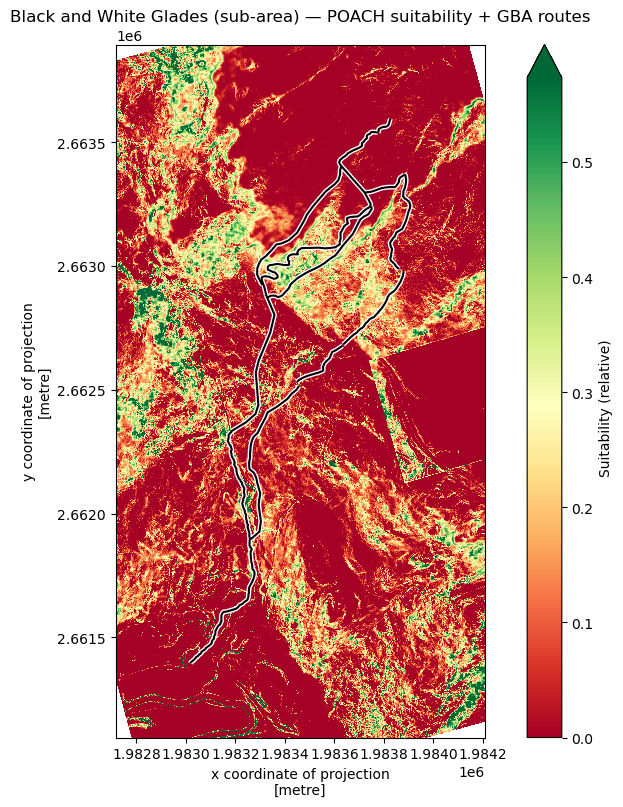

In [5]:
result_bw = run_zone(ZONES["black_and_white_sub"], scale=1.0)
s = result_bw["stats"]
print(f"{ZONES['black_and_white_sub']['name']}:")
print(f"  scene mean:  {s['scene_mean']:.3f}")
print(f"  routes:      {s['route_mean']:.3f}  ({s['route_mean']/s['scene_mean']:.1f}x)")
print(f"  descents:    {s['descent_mean']:.3f}  ({s['descent_mean']/s['scene_mean']:.1f}x)")

fig, ax = plot_overlay(result_bw["poach"], result_bw["routes"],
                       title="Black and White Glades (sub-area) — POACH suitability + GBA routes")
fig.savefig("../outputs/black_and_white_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## Result: the model does not generalize cleanly

At Black and White, the mapped routes score **below** the scene average
(~0.8× scene mean), in contrast to Maple Villa, where routes scored *above*
average (~1.2–1.3×). In other words, the model that showed a weak positive
signal on its development zone **fails to beat random on an independent zone.**

Inspecting the map, the GBA route largely follows a lower-angle drainage line,
while POACH assigns higher suitability to the steeper flanks on either side —
a genuine disagreement between the model's notion of "best terrain" and where
the glade was actually cut. This points to one or more of:

- **Overfitting to Maple Villa** — the pitch/aspect/overstory thresholds tuned
  on one zone may not encode anything general.
- **Real route-choice factors the model ignores** — access, fall-line flow,
  land boundaries, and aesthetics all influence where humans cut glades.
- **Zone and resolution differences** — Black and White is larger and of
  different forest and terrain character.

This is an honest negative result, and an important one: it demonstrates the
necessity of **multi-zone, out-of-sample validation** and shows that a simple
multiplicative suitability model tuned on a single zone should not be assumed
to generalize. Addressing it — through multi-zone calibration and improved
gap-detection — is the clearest direction for future work.